Scaling matrix S:
 [[3. 0.]
 [0. 3.]]
Translation to keep it centered: [-75. -75.]


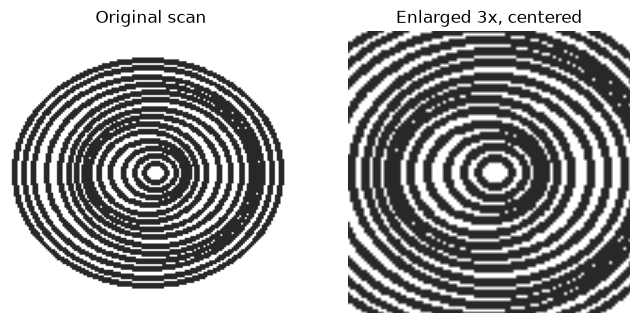

In [ ]:
## Task 1 
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

os.makedirs("Data", exist_ok=True)

# --- create a simple fingerprint-like test image (concentric ridges) ---
path = "Data/fingerprint.png"
size = 150
img = np.full((size, size, 3), 255, dtype=np.uint8)
center = (size // 2, size // 2)
for r in range(6, size // 2, 5):
    wobble = int(3 * np.sin(r / 6))
    cv2.ellipse(img, (center[0] + wobble, center[1]), (r, int(r * 0.85)), 0, 0, 360, (40, 40, 40), 2)
cv2.imwrite(path, img)


# Above code is Ai generated and is not part of the lab. The following code is the actual lab task.

img = cv2.imread(path)
h, w = img.shape[:2]

scale_factor = 3
S = np.array([[scale_factor, 0],
              [0, scale_factor]], dtype=np.float32)


new_w, new_h = w * 2, h * 2
old_center = np.array([w / 2, h / 2])
new_center = np.array([new_w / 2, new_h / 2])
translation = new_center - S @ old_center

M = np.hstack([S, translation.reshape(2, 1)]).astype(np.float32)
scaled = cv2.warpAffine(img, M, (new_w, new_h))

print("Scaling matrix S:\n", S)
print("Translation to keep it centered:", translation)

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)); axes[0].set_title("Original scan"); axes[0].axis("off")
axes[1].imshow(cv2.cvtColor(scaled, cv2.COLOR_BGR2RGB)); axes[1].set_title("Enlarged 3x, centered"); axes[1].axis("off")
plt.show()


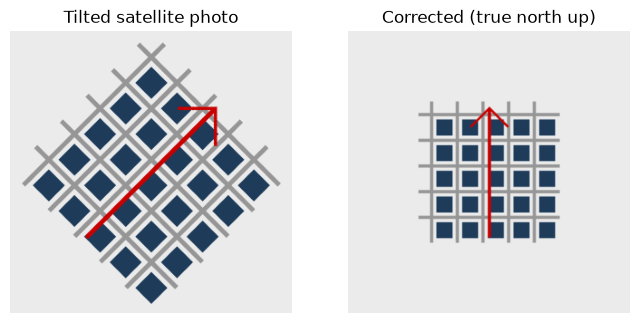

In [ ]:
# Task 2 
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

os.makedirs("Data", exist_ok=True)

# --- build a simple upright "city map": street grid + buildings + a north arrow ---
size = 220
city = np.full((size, size, 3), 235, dtype=np.uint8)
for x in range(20, size, 40):
    cv2.line(city, (x, 0), (x, size), (150, 150, 150), 4)
for y in range(20, size, 40):
    cv2.line(city, (0, y), (size, y), (150, 150, 150), 4)
for x in range(40, size, 40):
    for y in range(40, size, 40):
        cv2.rectangle(city, (x - 12, y - 12), (x + 12, y + 12), (90, 60, 30), -1)
cv2.arrowedLine(city, (size // 2, size - 10), (size // 2, 10), (0, 0, 200), 3, tipLength=0.2)

# simulate the drone photo coming in tilted 45 degrees 
h, w = city.shape[:2]
theta = np.radians(45)
R_tilt = np.array([[np.cos(theta), -np.sin(theta)], [np.sin(theta), np.cos(theta)]], dtype=np.float32)
cos_t, sin_t = abs(R_tilt[0, 0]), abs(R_tilt[0, 1])
tilt_w, tilt_h = int(h * sin_t + w * cos_t), int(h * cos_t + w * sin_t)
old_c, new_c = np.array([w / 2, h / 2]), np.array([tilt_w / 2, tilt_h / 2])
t_tilt = new_c - R_tilt @ old_c
M_tilt = np.hstack([R_tilt, t_tilt.reshape(2, 1)]).astype(np.float32)
tilted = cv2.warpAffine(city, M_tilt, (tilt_w, tilt_h), borderValue=(235, 235, 235))
cv2.imwrite("Data/satellite_city_tilted.png", tilted)

# Above code is Ai generated and is not part of the lab. The following code is the actual lab task.

img = cv2.imread("Data/satellite_city_tilted.png")
h, w = img.shape[:2]

angle = -45  
theta = np.radians(angle)
R = np.array([[np.cos(theta), -np.sin(theta)],
              [np.sin(theta),  np.cos(theta)]], dtype=np.float32)

cos_a, sin_a = abs(R[0, 0]), abs(R[0, 1])
new_w = int(h * sin_a + w * cos_a)
new_h = int(h * cos_a + w * sin_a)

old_center = np.array([w / 2, h / 2])
new_center = np.array([new_w / 2, new_h / 2])
translation = new_center - R @ old_center

M = np.hstack([R, translation.reshape(2, 1)]).astype(np.float32)
corrected = cv2.warpAffine(img, M, (new_w, new_h), borderValue=(235, 235, 235))

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)); axes[0].set_title("Tilted satellite photo"); axes[0].axis("off")
axes[1].imshow(cv2.cvtColor(corrected, cv2.COLOR_BGR2RGB)); axes[1].set_title("Corrected (true north up)"); axes[1].axis("off")
plt.show()


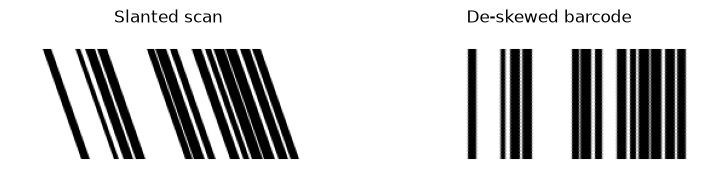

In [4]:
# Task 3
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

os.makedirs("Data", exist_ok=True)

# --- build a simple barcode (random-width vertical bars) ---
rng = np.random.default_rng(7)
h, w = 120, 220
barcode = np.full((h, w, 3), 255, dtype=np.uint8)
x = 10
while x < w - 10:
    bar_w = rng.integers(3, 9)
    if rng.random() < 0.55:
        cv2.rectangle(barcode, (x, 15), (x + bar_w, h - 15), (0, 0, 0), -1)
    x += bar_w + rng.integers(2, 6)

# --- simulate the scanner capturing it on a slant ---
shear_amount = 0.35
S_slant = np.array([[1, shear_amount], [0, 1]], dtype=np.float32)
slant_w = int(w + h * shear_amount)
M_slant = np.hstack([S_slant, [[0], [0]]]).astype(np.float32)
slanted = cv2.warpAffine(barcode, M_slant, (slant_w, h), borderValue=(255, 255, 255))
cv2.imwrite("Data/barcode_slanted.png", slanted)

# Above code is Ai generated and is not part of the lab. The following code is the actual lab task.

img = cv2.imread("Data/barcode_slanted.png")
h, w = img.shape[:2]

# undo the slant with the opposite horizontal shear
S_fix = np.array([[1, -shear_amount], [0, 1]], dtype=np.float32)

# shearing pushes content sideways, so shift it back into view
extra_shift = h * shear_amount
M_fix = np.hstack([S_fix, [[extra_shift], [0]]]).astype(np.float32)
straight = cv2.warpAffine(img, M_fix, (w, h), borderValue=(255, 255, 255))

fig, axes = plt.subplots(1, 2, figsize=(9, 3))
axes[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)); axes[0].set_title("Slanted scan"); axes[0].axis("off")
axes[1].imshow(cv2.cvtColor(straight, cv2.COLOR_BGR2RGB)); axes[1].set_title("De-skewed barcode"); axes[1].axis("off")
plt.show()


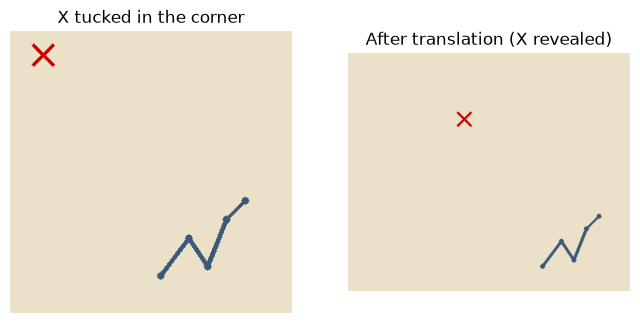

In [6]:
# Task 4
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

os.makedirs("Data", exist_ok=True)

# --- build a simple treasure map: a dotted path plus an X tucked in the corner ---
size = 300
treasure_map = np.full((size, size, 3), (200, 225, 235), dtype=np.uint8)
pts = [(160, 260), (190, 220), (210, 250), (230, 200), (250, 180)]
for a, b in zip(pts, pts[1:]):
    cv2.line(treasure_map, a, b, (120, 90, 60), 3)
for p in pts:
    cv2.circle(treasure_map, p, 4, (120, 90, 60), -1)

x_pos = (35, 25)  # the X, squeezed into the corner
cv2.line(treasure_map, (x_pos[0] - 10, x_pos[1] - 10), (x_pos[0] + 10, x_pos[1] + 10), (0, 0, 200), 4)
cv2.line(treasure_map, (x_pos[0] - 10, x_pos[1] + 10), (x_pos[0] + 10, x_pos[1] - 10), (0, 0, 200), 4)
cv2.imwrite("Data/treasure_map.png", treasure_map)


# Above code is Ai generated and is not part of the lab. The following code is the actual lab task.
img = cv2.imread("Data/treasure_map.png")
h, w = img.shape[:2]

tx, ty = 150, 80  
T = np.array([[1, 0, tx],
              [0, 1, ty],
              [0, 0, 1]], dtype=np.float32)  


new_w, new_h = w + tx, h + ty
revealed = cv2.warpAffine(img, T[:2, :], (new_w, new_h), borderValue=(200, 225, 235))

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)); axes[0].set_title("X tucked in the corner"); axes[0].axis("off")
axes[1].imshow(cv2.cvtColor(revealed, cv2.COLOR_BGR2RGB)); axes[1].set_title("After translation (X revealed)"); axes[1].axis("off")
plt.show()


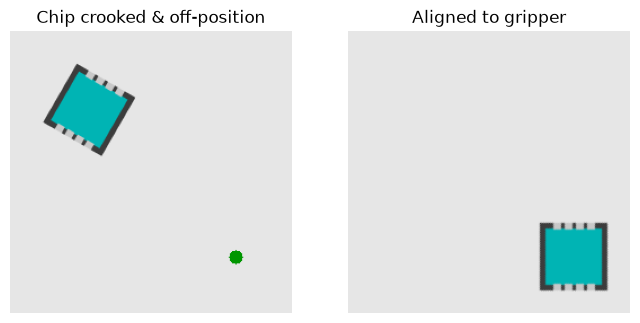

In [7]:
# Task 5
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

os.makedirs("Data", exist_ok=True)

# --- build a simple chip and place it crooked and off-position on the belt ---
size = 250
scene = np.full((size, size, 3), (230, 230, 230), dtype=np.uint8)

chip = np.zeros((60, 60, 3), dtype=np.uint8)
cv2.rectangle(chip, (0, 0), (59, 59), (60, 60, 60), -1)
cv2.rectangle(chip, (5, 5), (54, 54), (180, 180, 0), -1)
for i in range(4):
    cv2.rectangle(chip, (12 + i * 10, 0), (18 + i * 10, 5), (200, 200, 200), -1)
    cv2.rectangle(chip, (12 + i * 10, 54), (18 + i * 10, 59), (200, 200, 200), -1)

chip_center = (30, 30)
place_at = (70, 70)          # where the chip actually landed
theta = np.radians(30)       # how crooked it is
R0 = np.array([[np.cos(theta), -np.sin(theta)], [np.sin(theta), np.cos(theta)]], dtype=np.float32)
t0 = np.array(place_at) - R0 @ np.array(chip_center)
M0 = np.hstack([R0, t0.reshape(2, 1)]).astype(np.float32)
placed_chip = cv2.warpAffine(chip, M0, (size, size), borderValue=(230, 230, 230))
mask = cv2.cvtColor(placed_chip, cv2.COLOR_BGR2GRAY) > 0
scene[mask] = placed_chip[mask]
cv2.circle(scene, (200, 200), 6, (0, 150, 0), -1)  # gripper's target position
cv2.imwrite("Data/chip_scene.png", scene)

# Above code is Ai generated and is not part of the lab. The following code is the actual lab task.

img = cv2.imread("Data/chip_scene.png")

current_center = np.array(place_at, dtype=np.float32)     # (70, 70), from the vision system
current_angle = 30                                          # degrees, from the vision system
target_center = np.array([200, 200], dtype=np.float32)      # gripper position
target_angle = 0                                            # gripper wants it perfectly upright

fix_angle = np.radians(target_angle - current_angle)
R = np.array([[np.cos(fix_angle), -np.sin(fix_angle)],
              [np.sin(fix_angle),  np.cos(fix_angle)]], dtype=np.float32)

# rotate about the chip's own center, then move that center onto the gripper target
t = target_center - R @ current_center
M_rigid = np.hstack([R, t.reshape(2, 1)]).astype(np.float32)

h, w = img.shape[:2]
aligned = cv2.warpAffine(img, M_rigid, (w, h), borderValue=(230, 230, 230))

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)); axes[0].set_title("Chip crooked & off-position"); axes[0].axis("off")
axes[1].imshow(cv2.cvtColor(aligned, cv2.COLOR_BGR2RGB)); axes[1].set_title("Aligned to gripper"); axes[1].axis("off")
plt.show()


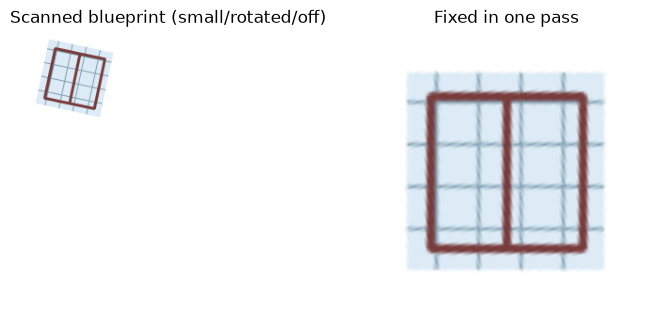

In [8]:
# Task 6
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

os.makedirs("Data", exist_ok=True)

# --- build a small blueprint (room outline + grid) ---
bp_size = 70
blueprint = np.full((bp_size, bp_size, 3), (245, 235, 220), dtype=np.uint8)
for v in range(10, bp_size, 15):
    cv2.line(blueprint, (v, 0), (v, bp_size), (180, 160, 130), 1)
    cv2.line(blueprint, (0, v), (bp_size, v), (180, 160, 130), 1)
cv2.rectangle(blueprint, (8, 8), (bp_size - 8, bp_size - 8), (60, 60, 120), 2)
cv2.line(blueprint, (bp_size // 2, 8), (bp_size // 2, bp_size - 8), (60, 60, 120), 2)

# --- scan it in: too small, rotated a bit, dumped in the top-left corner ---
page = 300
scan = np.full((page, page, 3), (255, 255, 255), dtype=np.uint8)
theta0 = np.radians(12)
R0 = np.array([[np.cos(theta0), -np.sin(theta0)], [np.sin(theta0), np.cos(theta0)]], dtype=np.float32)
place_at = (50, 50)
t0 = np.array(place_at) - R0 @ np.array([bp_size / 2, bp_size / 2])
M0 = np.hstack([R0, t0.reshape(2, 1)]).astype(np.float32)
placed = cv2.warpAffine(blueprint, M0, (page, page), borderValue=(255, 255, 255))
mask = cv2.cvtColor(placed, cv2.COLOR_BGR2GRAY) < 250
scan[mask] = placed[mask]
cv2.imwrite("Data/blueprint_scan.png", scan)

# Above code is Ai generated and is not part of the lab. The following code is the actual lab task.
img = cv2.imread("Data/blueprint_scan.png")
h, w = img.shape[:2]

current_center = np.array(place_at, dtype=np.float32)
current_angle, current_scale = 12, 1.0
target_center = np.array([w / 2, h / 2], dtype=np.float32)
target_angle, target_scale = 0, 3.0    # blueprint scanned too small, needs to be 3x bigger

s = target_scale / current_scale
fix_angle = np.radians(target_angle - current_angle)
SR = s * np.array([[np.cos(fix_angle), -np.sin(fix_angle)],
                    [np.sin(fix_angle),  np.cos(fix_angle)]], dtype=np.float32)

t = target_center - SR @ current_center
M_sim = np.hstack([SR, t.reshape(2, 1)]).astype(np.float32)  # combined similarity matrix

fixed = cv2.warpAffine(img, M_sim, (w, h), borderValue=(255, 255, 255))

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)); axes[0].set_title("Scanned blueprint (small/rotated/off)"); axes[0].axis("off")
axes[1].imshow(cv2.cvtColor(fixed, cv2.COLOR_BGR2RGB)); axes[1].set_title("Fixed in one pass"); axes[1].axis("off")
plt.show()


Recovered affine matrix:
 [[  0.8490566   -0.23584905  -6.8396225 ]
 [  0.09433962   1.0849056  -28.537735  ]]


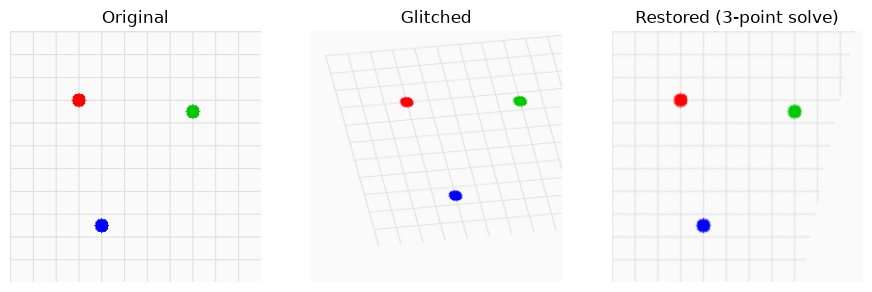

In [ ]:
# Task 7
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

os.makedirs("Data", exist_ok=True)

# --- build a simple photo with a background grid + 3 known landmark dots ---
size = 220
photo = np.full((size, size, 3), 250, dtype=np.uint8)
for v in range(0, size, 20):
    cv2.line(photo, (v, 0), (v, size), (225, 225, 225), 1)
    cv2.line(photo, (0, v), (size, v), (225, 225, 225), 1)

landmarks = np.array([[60, 60], [160, 70], [80, 170]], dtype=np.float32)
colors = [(0, 0, 255), (0, 200, 0), (255, 0, 0)]
for p, c in zip(landmarks, colors):
    cv2.circle(photo, tuple(p.astype(int)), 6, c, -1)
cv2.imwrite("Data/photo_original.png", photo)

# --- glitch it with some unknown general affine warp ---
glitch_matrix = np.array([[1.15, 0.25, 15], [-0.1, 0.9, 25]], dtype=np.float32)
glitched = cv2.warpAffine(photo, glitch_matrix, (size + 40, size + 40), borderValue=(250, 250, 250))
ones = np.ones((3, 1), dtype=np.float32)
glitched_landmarks = (glitch_matrix @ np.hstack([landmarks, ones]).T).T
cv2.imwrite("Data/photo_glitched.png", glitched)

# # Above code is Ai generated and is not part of the lab. The following code is the actual lab task.

img = cv2.imread("Data/photo_glitched.png")

src = glitched_landmarks.astype(np.float32)   # the 3 points as seen in the glitched photo
dst = landmarks.astype(np.float32)            # where those same 3 points should be

A = np.array([[x, y, 1] for x, y in src], dtype=np.float32)
abc = np.linalg.solve(A, dst[:, 0])  
defv = np.linalg.solve(A, dst[:, 1])  

M_fix = np.array([abc, defv], dtype=np.float32)
print("Recovered affine matrix:\n", M_fix)

restored = cv2.warpAffine(img, M_fix, (size, size), borderValue=(250, 250, 250))

fig, axes = plt.subplots(1, 3, figsize=(11, 4))
axes[0].imshow(cv2.cvtColor(photo, cv2.COLOR_BGR2RGB)); axes[0].set_title("Original"); axes[0].axis("off")
axes[1].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)); axes[1].set_title("Glitched"); axes[1].axis("off")
axes[2].imshow(cv2.cvtColor(restored, cv2.COLOR_BGR2RGB)); axes[2].set_title("Restored (3-point solve)"); axes[2].axis("off")
plt.show()


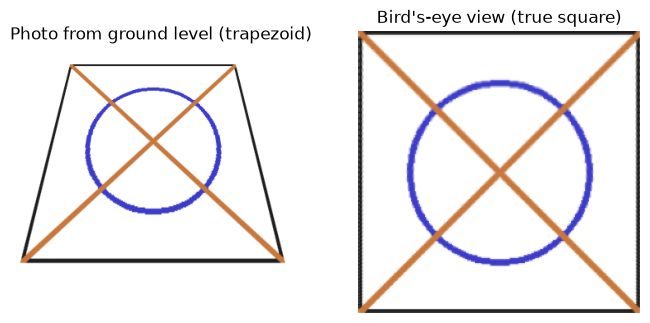

In [11]:
# TAsk 8
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

os.makedirs("Data", exist_ok=True)

# --- build a top-down "chalk art" square with a pattern inside ---
side = 220
art = np.full((side, side, 3), 255, dtype=np.uint8)
cv2.rectangle(art, (0, 0), (side - 1, side - 1), (30, 30, 30), 4)
cv2.circle(art, (side // 2, side // 2), 70, (200, 60, 60), 4)
cv2.line(art, (0, 0), (side, side), (60, 120, 200), 3)
cv2.line(art, (side, 0), (0, side), (60, 120, 200), 3)

# --- simulate the low camera angle: the far edge looks smaller (a trapezoid) ---
src_square = np.float32([[0, 0], [side, 0], [side, side], [0, side]])
dst_trapezoid = np.float32([[60, 20], [260, 20], [320, 260], [0, 260]])
M_capture = cv2.getPerspectiveTransform(src_square, dst_trapezoid)
photo = cv2.warpPerspective(art, M_capture, (340, 300), borderValue=(255, 255, 255))
cv2.imwrite("Data/chalk_art_photo.png", photo)

# Above code is Ai generated and is not part of the lab. The following code is the actual lab task.
img = cv2.imread("Data/chalk_art_photo.png")

src_pts = np.float32([[60, 20], [260, 20], [320, 260], [0, 260]])   # chalk square's corners in the photo
dst_pts = np.float32([[0, 0], [side, 0], [side, side], [0, side]])  # where a true square's corners should be

M = cv2.getPerspectiveTransform(src_pts, dst_pts)
birds_eye = cv2.warpPerspective(img, M, (side, side), borderValue=(255, 255, 255))

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)); axes[0].set_title("Photo from ground level (trapezoid)"); axes[0].axis("off")
axes[1].imshow(cv2.cvtColor(birds_eye, cv2.COLOR_BGR2RGB)); axes[1].set_title("Bird\'s-eye view (true square)"); axes[1].axis("off")
plt.show()


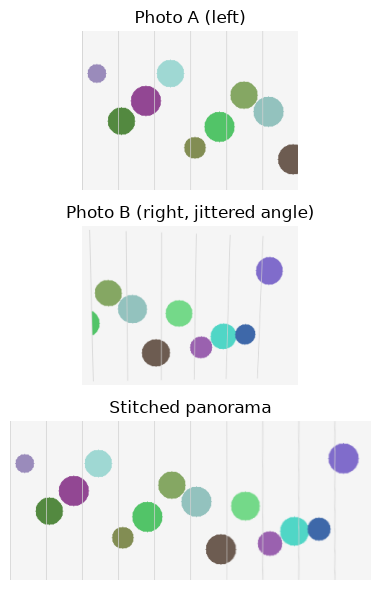

In [12]:
# Task 9
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

os.makedirs("Data", exist_ok=True)

# --- build one wide "scene" (a wall mural) then take two overlapping photos of it ---
scene_w, scene_h = 500, 220
scene = np.full((scene_h, scene_w, 3), (245, 245, 245), dtype=np.uint8)
rng = np.random.default_rng(11)
for i in range(14):
    x = 20 + i * 34
    y = rng.integers(40, scene_h - 40)
    r = rng.integers(12, 22)
    color = tuple(int(c) for c in rng.integers(60, 220, size=3))
    cv2.circle(scene, (x, y), r, color, -1)
for x in range(0, scene_w, 50):
    cv2.line(scene, (x, 0), (x, scene_h), (210, 210, 210), 1)

photo_a = scene[:, 0:300].copy()          # photo A: left part of the scene
right_crop = scene[:, 200:500].copy()     # photo B: right part, same scene
h, w = right_crop.shape[:2]
src = np.float32([[0, 0], [w, 0], [w, h], [0, h]])
dst = np.float32([[10, 5], [w - 5, 15], [w - 15, h - 10], [15, h - 5]])
M_jitter = cv2.getPerspectiveTransform(src, dst)   # photo B taken from a slightly different angle
photo_b = cv2.warpPerspective(right_crop, M_jitter, (w, h), borderValue=(245, 245, 245))

cv2.imwrite("Data/panorama_left.png", photo_a)
cv2.imwrite("Data/panorama_right.png", photo_b)

# Above code is Ai generated and is not part of the lab. The following code is the actual lab task.
img_left = cv2.imread("Data/panorama_left.png")
img_right = cv2.imread("Data/panorama_right.png")

pts_right = np.float32([[10, 5], [w - 5, 15], [w - 15, h - 10], [15, h - 5]])  # as seen in photo B
pts_left  = np.float32([[200, 0], [500, 0], [500, h], [200, h]])               # the same points in photo A's frame

H = cv2.getPerspectiveTransform(pts_right, pts_left)  
canvas_w, canvas_h = 500, 220
panorama = cv2.warpPerspective(img_right, H, (canvas_w, canvas_h), borderValue=(245, 245, 245))
panorama[:, 0:img_left.shape[1]] = img_left 

fig, axes = plt.subplots(3, 1, figsize=(7, 6))
axes[0].imshow(cv2.cvtColor(img_left, cv2.COLOR_BGR2RGB)); axes[0].set_title("Photo A (left)"); axes[0].axis("off")
axes[1].imshow(cv2.cvtColor(img_right, cv2.COLOR_BGR2RGB)); axes[1].set_title("Photo B (right, jittered angle)"); axes[1].axis("off")
axes[2].imshow(cv2.cvtColor(panorama, cv2.COLOR_BGR2RGB)); axes[2].set_title("Stitched panorama"); axes[2].axis("off")
plt.tight_layout()
plt.show()


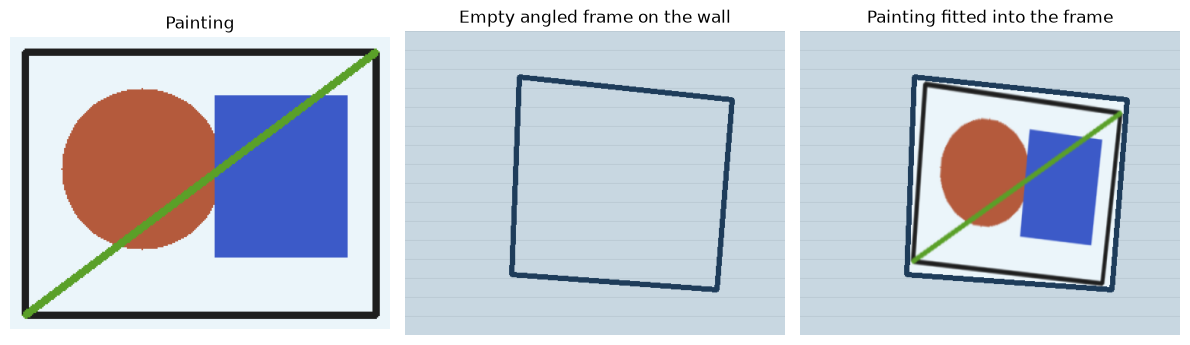

In [13]:
#Task 10
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

os.makedirs("Data", exist_ok=True)

# --- the painting: a simple piece of abstract art ---
painting = np.full((200, 260, 3), (250, 245, 235), dtype=np.uint8)
cv2.rectangle(painting, (10, 10), (250, 190), (30, 30, 30), 3)
cv2.circle(painting, (90, 90), 55, (60, 90, 180), -1)
cv2.rectangle(painting, (140, 40), (230, 150), (200, 90, 60), -1)
cv2.line(painting, (10, 190), (250, 10), (40, 160, 90), 4)
cv2.imwrite("Data/painting.png", painting)

# --- the museum wall: photographed at a slight angle, with an empty angled frame ---
wall = np.full((400, 500, 3), (225, 215, 200), dtype=np.uint8)
for y in range(0, 400, 25):
    cv2.line(wall, (0, y), (500, y), (210, 200, 185), 1)
frame_corners = np.float32([[150, 60], [430, 90], [410, 340], [140, 320]])
cv2.polylines(wall, [frame_corners.astype(int)], True, (90, 60, 30), 6)
cv2.imwrite("Data/museum_wall.png", wall)

# Above code is Ai generated and is not part of the lab. The following code is the actual lab task.

art = cv2.imread("Data/painting.png")
wall_img = cv2.imread("Data/museum_wall.png")
ah, aw = art.shape[:2]
wh, ww = wall_img.shape[:2]

# 1) LINEAR: scale the painting down to roughly the frame's size
scale_x, scale_y = 0.9, 0.9
S = np.array([[scale_x, 0], [0, scale_y]], dtype=np.float32)
scaled_w, scaled_h = int(aw * scale_x), int(ah * scale_y)
scaled_art = cv2.warpAffine(art, np.hstack([S, [[0], [0]]]).astype(np.float32),
                             (scaled_w, scaled_h), borderValue=(250, 245, 235))

# 2) RIGID: give it a small 2-degree nudge in place (rotation + translation, no distortion)
theta = np.radians(2)
R = np.array([[np.cos(theta), -np.sin(theta)], [np.sin(theta), np.cos(theta)]], dtype=np.float32)
center = np.array([scaled_w / 2, scaled_h / 2])
t = center - R @ center
M_rigid = np.hstack([R, t.reshape(2, 1)]).astype(np.float32)
posed_art = cv2.warpAffine(scaled_art, M_rigid, (scaled_w, scaled_h), borderValue=(250, 245, 235))

# 3) PROJECTIVE: map the painting's 4 corners onto the frame's 4 angled corners
src_corners = np.float32([[0, 0], [scaled_w, 0], [scaled_w, scaled_h], [0, scaled_h]])
M_persp = cv2.getPerspectiveTransform(src_corners, frame_corners)
warped_art = cv2.warpPerspective(posed_art, M_persp, (ww, wh))

# only paint inside the frame opening on the wall
mask = np.zeros((wh, ww), dtype=np.uint8)
cv2.fillConvexPoly(mask, frame_corners.astype(int), 255)
result = wall_img.copy()
result[mask > 0] = warped_art[mask > 0]
cv2.polylines(result, [frame_corners.astype(int)], True, (90, 60, 30), 6)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(cv2.cvtColor(art, cv2.COLOR_BGR2RGB)); axes[0].set_title("Painting"); axes[0].axis("off")
axes[1].imshow(cv2.cvtColor(wall_img, cv2.COLOR_BGR2RGB)); axes[1].set_title("Empty angled frame on the wall"); axes[1].axis("off")
axes[2].imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB)); axes[2].set_title("Painting fitted into the frame"); axes[2].axis("off")
plt.tight_layout()
plt.show()
